In [121]:
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

wine_data = datasets.load_wine()
wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)  

## **Objetivos especificos**

### **Aplicar Regresión lineal de sklearn**

### **1. Obtener relación entre total_phenole y flavanoids**

1. obtener función de línea

2. dibujar la linea, junto con los datos

3. obtener Score

### **2. Obtener relación entre hue y color_intensity**

1. obtener función de línea
2. dibujar la linea, junto con los datos
3. obtener Score   
  
### **3. Analizar relaciones de dos factores (total_phenole y flavenoids) y (hue y color_intensity)**
  
### **4. Seleccionar dos factores de caracteristicas de vinos que mejor relacionado  linealmente**
  

In [114]:
def train_model(colum1, colum2):
    X = wine[[colum1]].values
    y = wine[colum2]

    mmn = MinMaxScaler()
    X_mmn = mmn.fit_transform(X)

    X_train, X_test, y_train, y_test  = train_test_split(
        X_mmn, y, 
        test_size=0.1, 
        random_state=0
    )
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    inclinacion = modelo.coef_[0]
    b = modelo.intercept_

    score_train = modelo.score(X_train, y_train)
    score_test = modelo.score(X_test, y_test)
    
    funcionLinea = X_mmn * inclinacion + b
    
    data = X_mmn, y, funcionLinea
    coeficientes = inclinacion, b
    scores = score_train, score_test
    return data, coeficientes, scores

def drawLine(X_mmn, y, funcionLinea, colum1, colum2):
    plt.title(f'Relación {colum1} vs {colum2}')
    plt.scatter(X_mmn, y, c='g')
    plt.plot(X_mmn, funcionLinea, c='r')
    plt.show()
    return 

def printDescrip(coef, scores, onlyScore=False):
    if not onlyScore:
        print(f'Coeficiente : {coef[0]}')
        print(f'Intersección : {b}')
        print(f'Funcion de linea : {coef[0]}x + {coef[1]}')
    print(f"{' Scores de train y test ':=^30}")
    print(f'training score = {scores[0]*100:7.3f}%')
    print(f'test score = {scores[1]*100:7.3f}%')

In [ ]:
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### **Punto 1. Relación entre total_phenole y flavanoids**

In [115]:
feature1, feature2 = 'total_phenols', 'flavanoids'
data, coef, scores = train_model(feature1, feature2)
printDescrip(coef, scores)

Coeficiente : 3.9781807766337636
Intersección : 7.619424846064385
Funcion de linea : 3.9781807766337636x + 0.20940113270834515
=== Scores de train y test ===
training score =  74.236%
test score =  75.203%


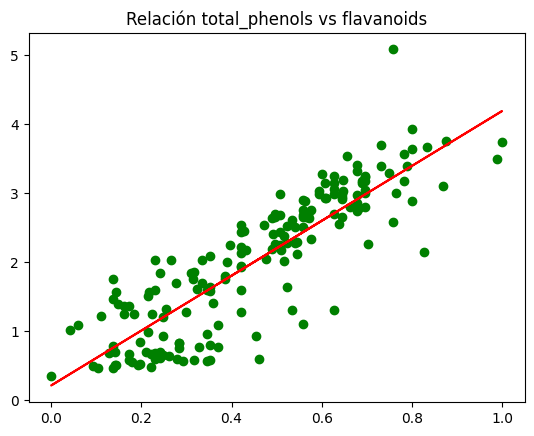

In [116]:
drawLine(data[0], data[1], data[2], feature1, feature2)

### **Punto 2. Relación entre hue y color_intensity**

In [117]:
feature1 = 'hue'
feature2 = 'color_intensity'

data, coef, scores = train_model(feature1, feature2)
printDescrip(coef, scores)

Coeficiente : -6.739339873467601
Intersección : 7.619424846064385
Funcion de linea : -6.739339873467601x + 7.619424846064385
=== Scores de train y test ===
training score =  28.430%
test score =   9.286%


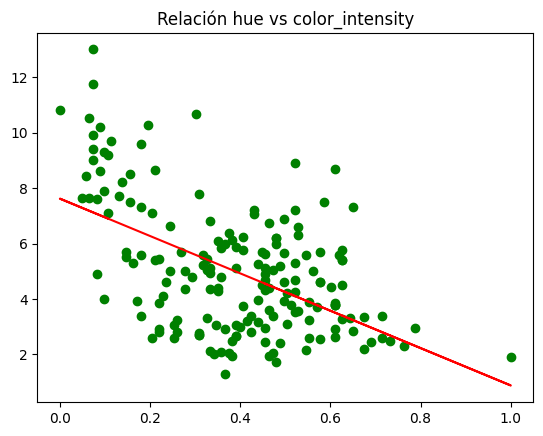

In [118]:
drawLine(data[0], data[1], data[2], feature1, feature2)

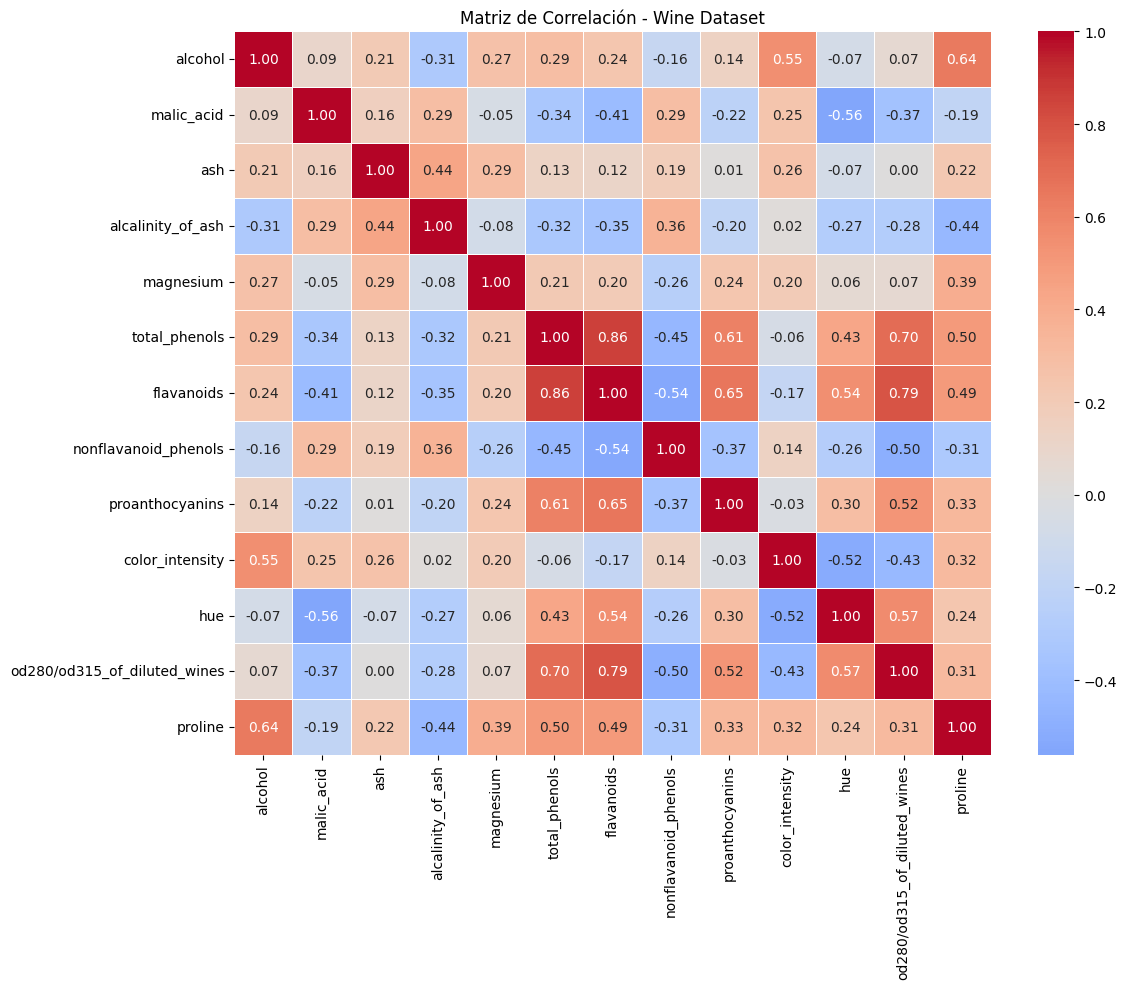

In [122]:
matriz_correlacion = wine.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f',
            linewidths=0.5)
plt.title('Matriz de Correlación - Wine Dataset')
plt.tight_layout()
plt.show()

In [ ]:

correlaciones_pares = []
features = wine.columns.values
for i in range(len(features)):
    for j in range(i+1, len(features)):
        corr_val = matriz_correlacion.iloc[i, j]
        correlaciones_pares.append((
            features[i], 
            features[j], 
            abs(corr_val), 
            corr_val
        ))

correlaciones_pares.sort(key=lambda x: x[2], reverse=True)

print("\nTOP 10 - PAREJAS CON MAYOR CORRELACIÓN:")
print("=" * 50)
for var1, var2, abs_corr, corr in correlaciones_pares[:10]:
    print(f"{var1:15} - {var2:30}: {corr:7.4f}")


TOP 10 - PAREJAS CON MAYOR CORRELACIÓN:
total_phenols   - flavanoids                    :  0.8646
flavanoids      - od280/od315_of_diluted_wines  :  0.7872
total_phenols   - od280/od315_of_diluted_wines  :  0.6999
flavanoids      - proanthocyanins               :  0.6527
alcohol         - proline                       :  0.6437
total_phenols   - proanthocyanins               :  0.6124
hue             - od280/od315_of_diluted_wines  :  0.5655
malic_acid      - hue                           : -0.5613
alcohol         - color_intensity               :  0.5464
flavanoids      - hue                           :  0.5435


In [120]:
for var1, var2, abs_corr, corr in correlaciones_pares[:10]:
    data, coef, scores = train_model(var1, var2)
    print(f'Modelo con parametros {var1} y {var2} ')
    printDescrip(coef, scores, onlyScore=True)
    print()

Modelo con parametros total_phenols y flavanoids 
=== Scores de train y test ===
training score =  74.236%
test score =  75.203%

Modelo con parametros flavanoids y od280/od315_of_diluted_wines 
=== Scores de train y test ===
training score =  63.790%
test score =  41.577%

Modelo con parametros total_phenols y od280/od315_of_diluted_wines 
=== Scores de train y test ===
training score =  50.881%
test score =  28.624%

Modelo con parametros flavanoids y proanthocyanins 
=== Scores de train y test ===
training score =  43.636%
test score =  21.970%

Modelo con parametros alcohol y proline 
=== Scores de train y test ===
training score =  39.109%
test score =  51.165%

Modelo con parametros total_phenols y proanthocyanins 
=== Scores de train y test ===
training score =  37.889%
test score =  28.362%

Modelo con parametros hue y od280/od315_of_diluted_wines 
=== Scores de train y test ===
training score =  30.770%
test score =  42.568%

Modelo con parametros malic_acid y hue 
=== Scores 